Symptom Graph Analysis

In [1]:
# =========================================================
# 1. Imports
# =========================================================
import warnings
warnings.filterwarnings("ignore")

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.covariance import GraphicalLassoCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_absolute_error,
    confusion_matrix,
    classification_report,
    cohen_kappa_score,
    matthews_corrcoef
)



In [2]:
df = pd.read_csv("/content/Processed.csv")
data = df.copy()
data.columns = [c.strip() for c in data.columns]

print("Dataset shape:", data.shape)
print("\nColumns:")
print(data.columns.tolist())


Dataset shape: (2028, 39)

Columns:
['Age', 'Gender', 'University', 'Department', 'Academic_Year', 'Current_CGPA', 'waiver_or_scholarship', 'PSS1', 'PSS2', 'PSS3', 'PSS4', 'PSS5', 'PSS6', 'PSS7', 'PSS8', 'PSS9', 'PSS10', 'Stress Value', 'Stress Label', 'GAD1', 'GAD2', 'GAD3', 'GAD4', 'GAD5', 'GAD6', 'GAD7', 'Anxiety Value', 'Anxiety Label', 'PHQ1', 'PHQ2', 'PHQ3', 'PHQ4', 'PHQ5', 'PHQ6', 'PHQ7', 'PHQ8', 'PHQ9', 'Depression Value', 'Depression Label']


In [4]:

# =========================================================
# 4. Column definitions
# =========================================================
# Reduced symptom set
symptom_cols = [
    'PSS1', 'PSS2', 'PSS3', 'PSS4', 'PSS5', 'PSS6', 'PSS7', 'PSS8', 'PSS9', 'PSS10',
    'GAD1', 'GAD2', 'GAD3', 'GAD4', 'GAD5', 'GAD6', 'GAD7',
    'PHQ1', 'PHQ2', 'PHQ3', 'PHQ4', 'PHQ5', 'PHQ6', 'PHQ7', 'PHQ8', 'PHQ9'
]

stress_cols = ['PSS1', 'PSS2', 'PSS3', 'PSS4', 'PSS5', 'PSS6', 'PSS7', 'PSS8', 'PSS9', 'PSS10']
anxiety_cols = ['GAD1', 'GAD2', 'GAD3', 'GAD4', 'GAD5', 'GAD6', 'GAD7']
depression_cols = ['PHQ1', 'PHQ2', 'PHQ3', 'PHQ4', 'PHQ5', 'PHQ6', 'PHQ7', 'PHQ8', 'PHQ9']

drop_leakage_cols = [
    'Stress Value',
    'Anxiety Value',
    'Depression Value'
]

target_cols = [
    'Stress Label',
    'Anxiety Label',
    'Depression Label'
]

required_cols = symptom_cols + target_cols + drop_leakage_cols
missing_cols = [c for c in required_cols if c not in data.columns]

if missing_cols:
    raise ValueError(f"Missing columns: {missing_cols}")
else:
    print("All required columns are present.")


All required columns are present.


In [5]:
# =========================================================
# 5. Remove leakage columns
# =========================================================
data = data.drop(columns=drop_leakage_cols)
print("Shape after dropping leakage columns:", data.shape)


# =========================================================
# 6. Clean target text
# =========================================================
def clean_text(x):
    if pd.isna(x):
        return np.nan
    return str(x).strip()

for col in target_cols:
    data[col] = data[col].apply(clean_text)

def map_anxiety_label(x):
    x = str(x).strip().lower()
    if x == 'minimal anxiety':
        return 0
    elif x == 'mild anxiety':
        return 1
    elif x == 'moderate anxiety':
        return 2
    elif x == 'severe anxiety':
        return 3
    return np.nan

def map_stress_label(x):
    x = str(x).strip().lower()
    if x == 'low stress':
        return 0
    elif x == 'moderate stress':
        return 1
    elif x == 'high perceived stress':
        return 2
    return np.nan


def map_depression_label(x):
    x = str(x).strip().lower()
    if x in ['no depression', 'minimal depression']:
        return 0
    elif x == 'mild depression':
        return 1
    elif x == 'moderate depression':
        return 2
    elif x in ['moderately severe depression', 'severe depression']:
        return 3
    return np.nan

data['Stress_Target'] = data['Stress Label'].apply(map_stress_label)
data['Anxiety_Target'] = data['Anxiety Label'].apply(map_anxiety_label)
data['Depression_Target'] = data['Depression Label'].apply(map_depression_label)

data = data.dropna(subset=['Anxiety_Target', 'Depression_Target']).reset_index(drop=True)

data['Stress_Target'] = data['Stress_Target'].astype(int)
data['Anxiety_Target'] = data['Anxiety_Target'].astype(int)
data['Depression_Target'] = data['Depression_Target'].astype(int)

num_stress_classes = 3
num_anxiety_classes = 4
num_depression_classes = 4

print(data[['Stress Label', 'Stress_Target']].drop_duplicates().sort_values('Stress_Target'))
print(data[['Anxiety Label', 'Anxiety_Target']].drop_duplicates().sort_values('Anxiety_Target'))
print(data[['Depression Label', 'Depression_Target']].drop_duplicates().sort_values('Depression_Target'))


# print(data[['Stress Label', 'Stress_Target']].drop_duplicates().sort_values('Stress_Target'))
# print(data[['Anxiety Label', 'Anxiety_Target']].drop_duplicates().sort_values('Anxiety_Target'))
# print(data[['Depression Label', 'Depression_Target']].drop_duplicates().sort_values('Depression_Target'))


Shape after dropping leakage columns: (2028, 36)
            Stress Label  Stress_Target
7             Low Stress              0
1        Moderate Stress              1
0  High Perceived Stress              2
      Anxiety Label  Anxiety_Target
2   Minimal Anxiety               0
5      Mild Anxiety               1
1  Moderate Anxiety               2
0    Severe Anxiety               3
                Depression Label  Depression_Target
2                  No Depression                  0
6             Minimal Depression                  0
10               Mild Depression                  1
3            Moderate Depression                  2
0              Severe Depression                  3
1   Moderately Severe Depression                  3


In [6]:


# =========================================================
# 9. Prepare symptom matrix
# =========================================================
X_symptom = data[symptom_cols].copy()

symptom_imputer = SimpleImputer(strategy='median')
X_symptom_imputed = symptom_imputer.fit_transform(X_symptom)

symptom_scaler = StandardScaler()
X_symptom_scaled = symptom_scaler.fit_transform(X_symptom_imputed)

print("Symptom matrix shape:", X_symptom_scaled.shape)
print("First 3 rows after scaling:\n", X_symptom_scaled[:3])


Symptom matrix shape: (2028, 26)
First 3 rows after scaling:
 [[ 0.5513849   1.4467218   0.25785107 -0.30213417 -0.15962365 -0.71998272
   0.06626399  0.24565727  1.33715904  1.34106426  0.23307104  0.35613152
   1.25059497  0.22530815  0.13658529  0.20419359  0.25288159  0.56135718
   0.19782292  1.26306926  0.04402909  0.47697301  0.1948299   0.3501842
   1.52066023  0.72135678]
 [ 0.5513849   0.58201452  1.14116521 -0.30213417  0.76264634  0.19031962
   0.06626399  0.24565727 -0.36193778  0.48366252 -0.81730244  0.35613152
   0.24655435 -0.8108028  -0.88177858  1.21174735  0.25288159  1.60771045
   0.19782292  0.31856172  0.04402909  0.47697301  0.1948299   0.3501842
   0.54659234  0.72135678]
 [-1.99385466 -2.01210733 -2.39209134 -1.93825728 -2.00416364 -0.71998272
  -1.89553692 -1.5209844  -2.06103461 -2.08854271 -1.86767591 -1.5905928
  -1.76152688 -1.84691375 -1.90014246 -1.81091394 -1.6395312  -1.53134936
  -1.73559819 -1.57045337 -2.00863745 -1.43847503 -1.66892028 -1.59816577

In [7]:

# =========================================================
# 10. Construct symptom graph using Graphical LASSO
# =========================================================
glasso = GraphicalLassoCV()
glasso.fit(X_symptom_scaled)

precision_matrix = glasso.precision_

def precision_to_partial_corr(precision):
    d = np.sqrt(np.diag(precision))
    partial_corr = -precision / np.outer(d, d)
    np.fill_diagonal(partial_corr, 0.0)
    return partial_corr

partial_corr_matrix = precision_to_partial_corr(precision_matrix)

threshold = 0.05
adj_matrix = partial_corr_matrix.copy()
adj_matrix[np.abs(adj_matrix) < threshold] = 0.0

src, dst = np.nonzero(adj_matrix)
edge_index = torch.tensor(np.vstack((src, dst)), dtype=torch.long)
edge_weight = torch.tensor(adj_matrix[src, dst], dtype=torch.float)

print("Number of nodes:", len(symptom_cols))
print("Number of edges:", edge_index.shape[1])



Number of nodes: 26
Number of edges: 144


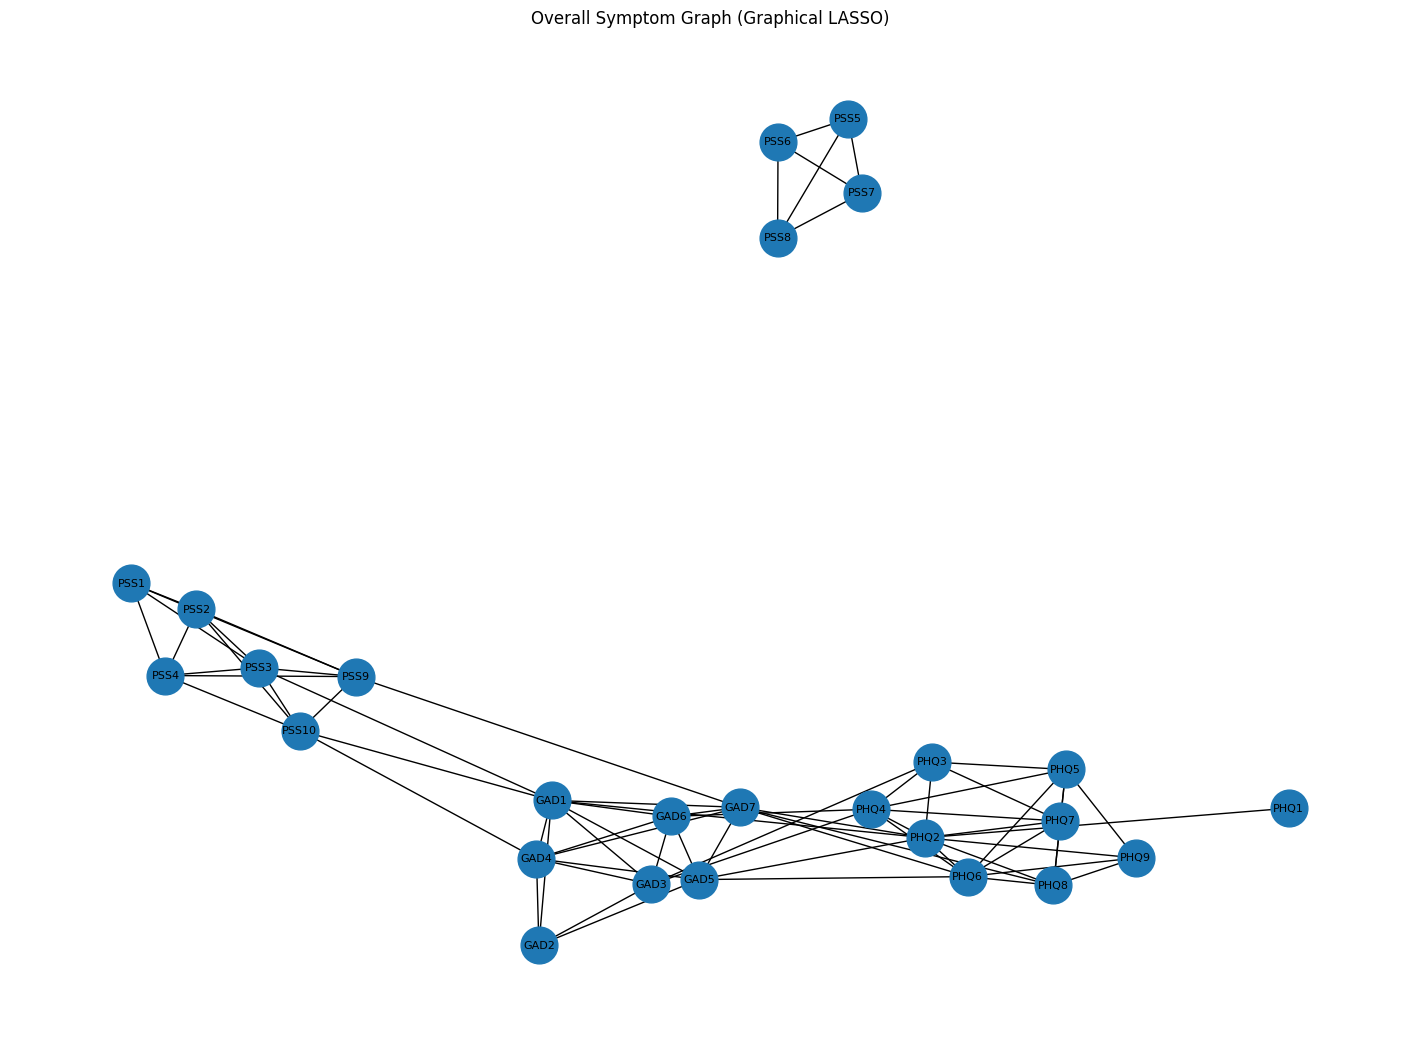

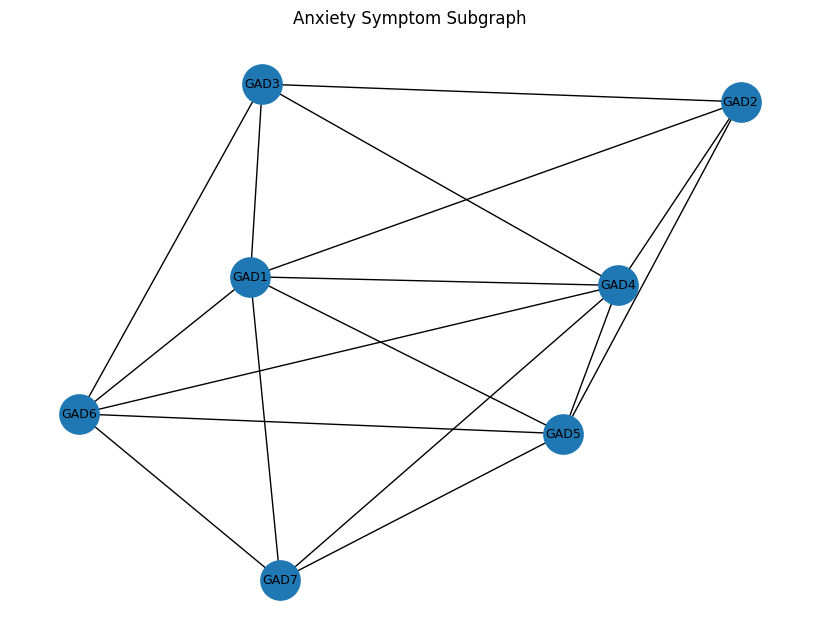

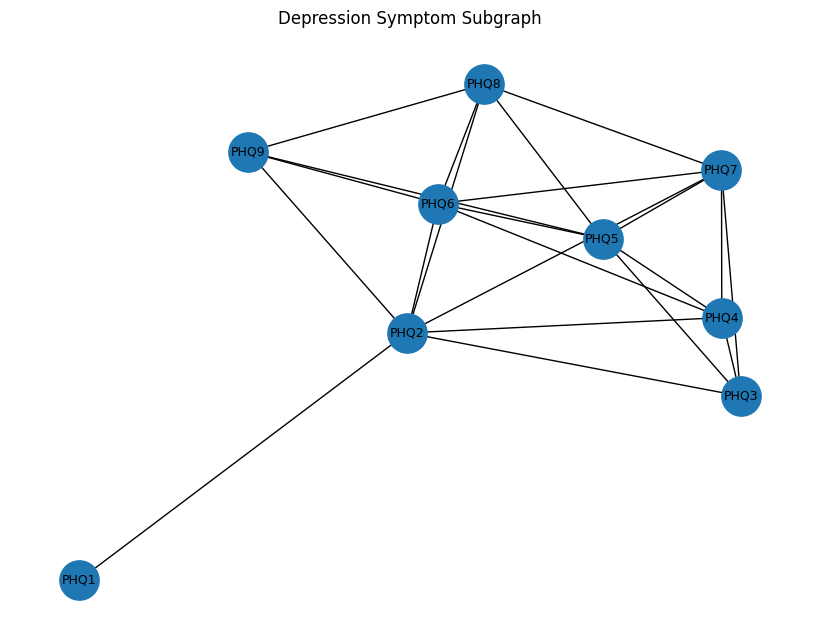

In [8]:
# =========================================================
# 11. Visualize graph
# =========================================================
G = nx.from_numpy_array(adj_matrix)
mapping = {i: symptom_cols[i] for i in range(len(symptom_cols))}
G = nx.relabel_nodes(G, mapping)

plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_size=700, font_size=8)
plt.title("Overall Symptom Graph (Graphical LASSO)")
plt.show()

def plot_subgraph(node_names, title):
    SG = G.subgraph(node_names)
    plt.figure(figsize=(8, 6))
    pos = nx.spring_layout(SG, seed=42)
    nx.draw(SG, pos, with_labels=True, node_size=800, font_size=9)
    plt.title(title)
    plt.show()

# plot_subgraph(stress_cols, "Stress Symptom Subgraph")
plot_subgraph(anxiety_cols, "Anxiety Symptom Subgraph")
plot_subgraph(depression_cols, "Depression Symptom Subgraph")

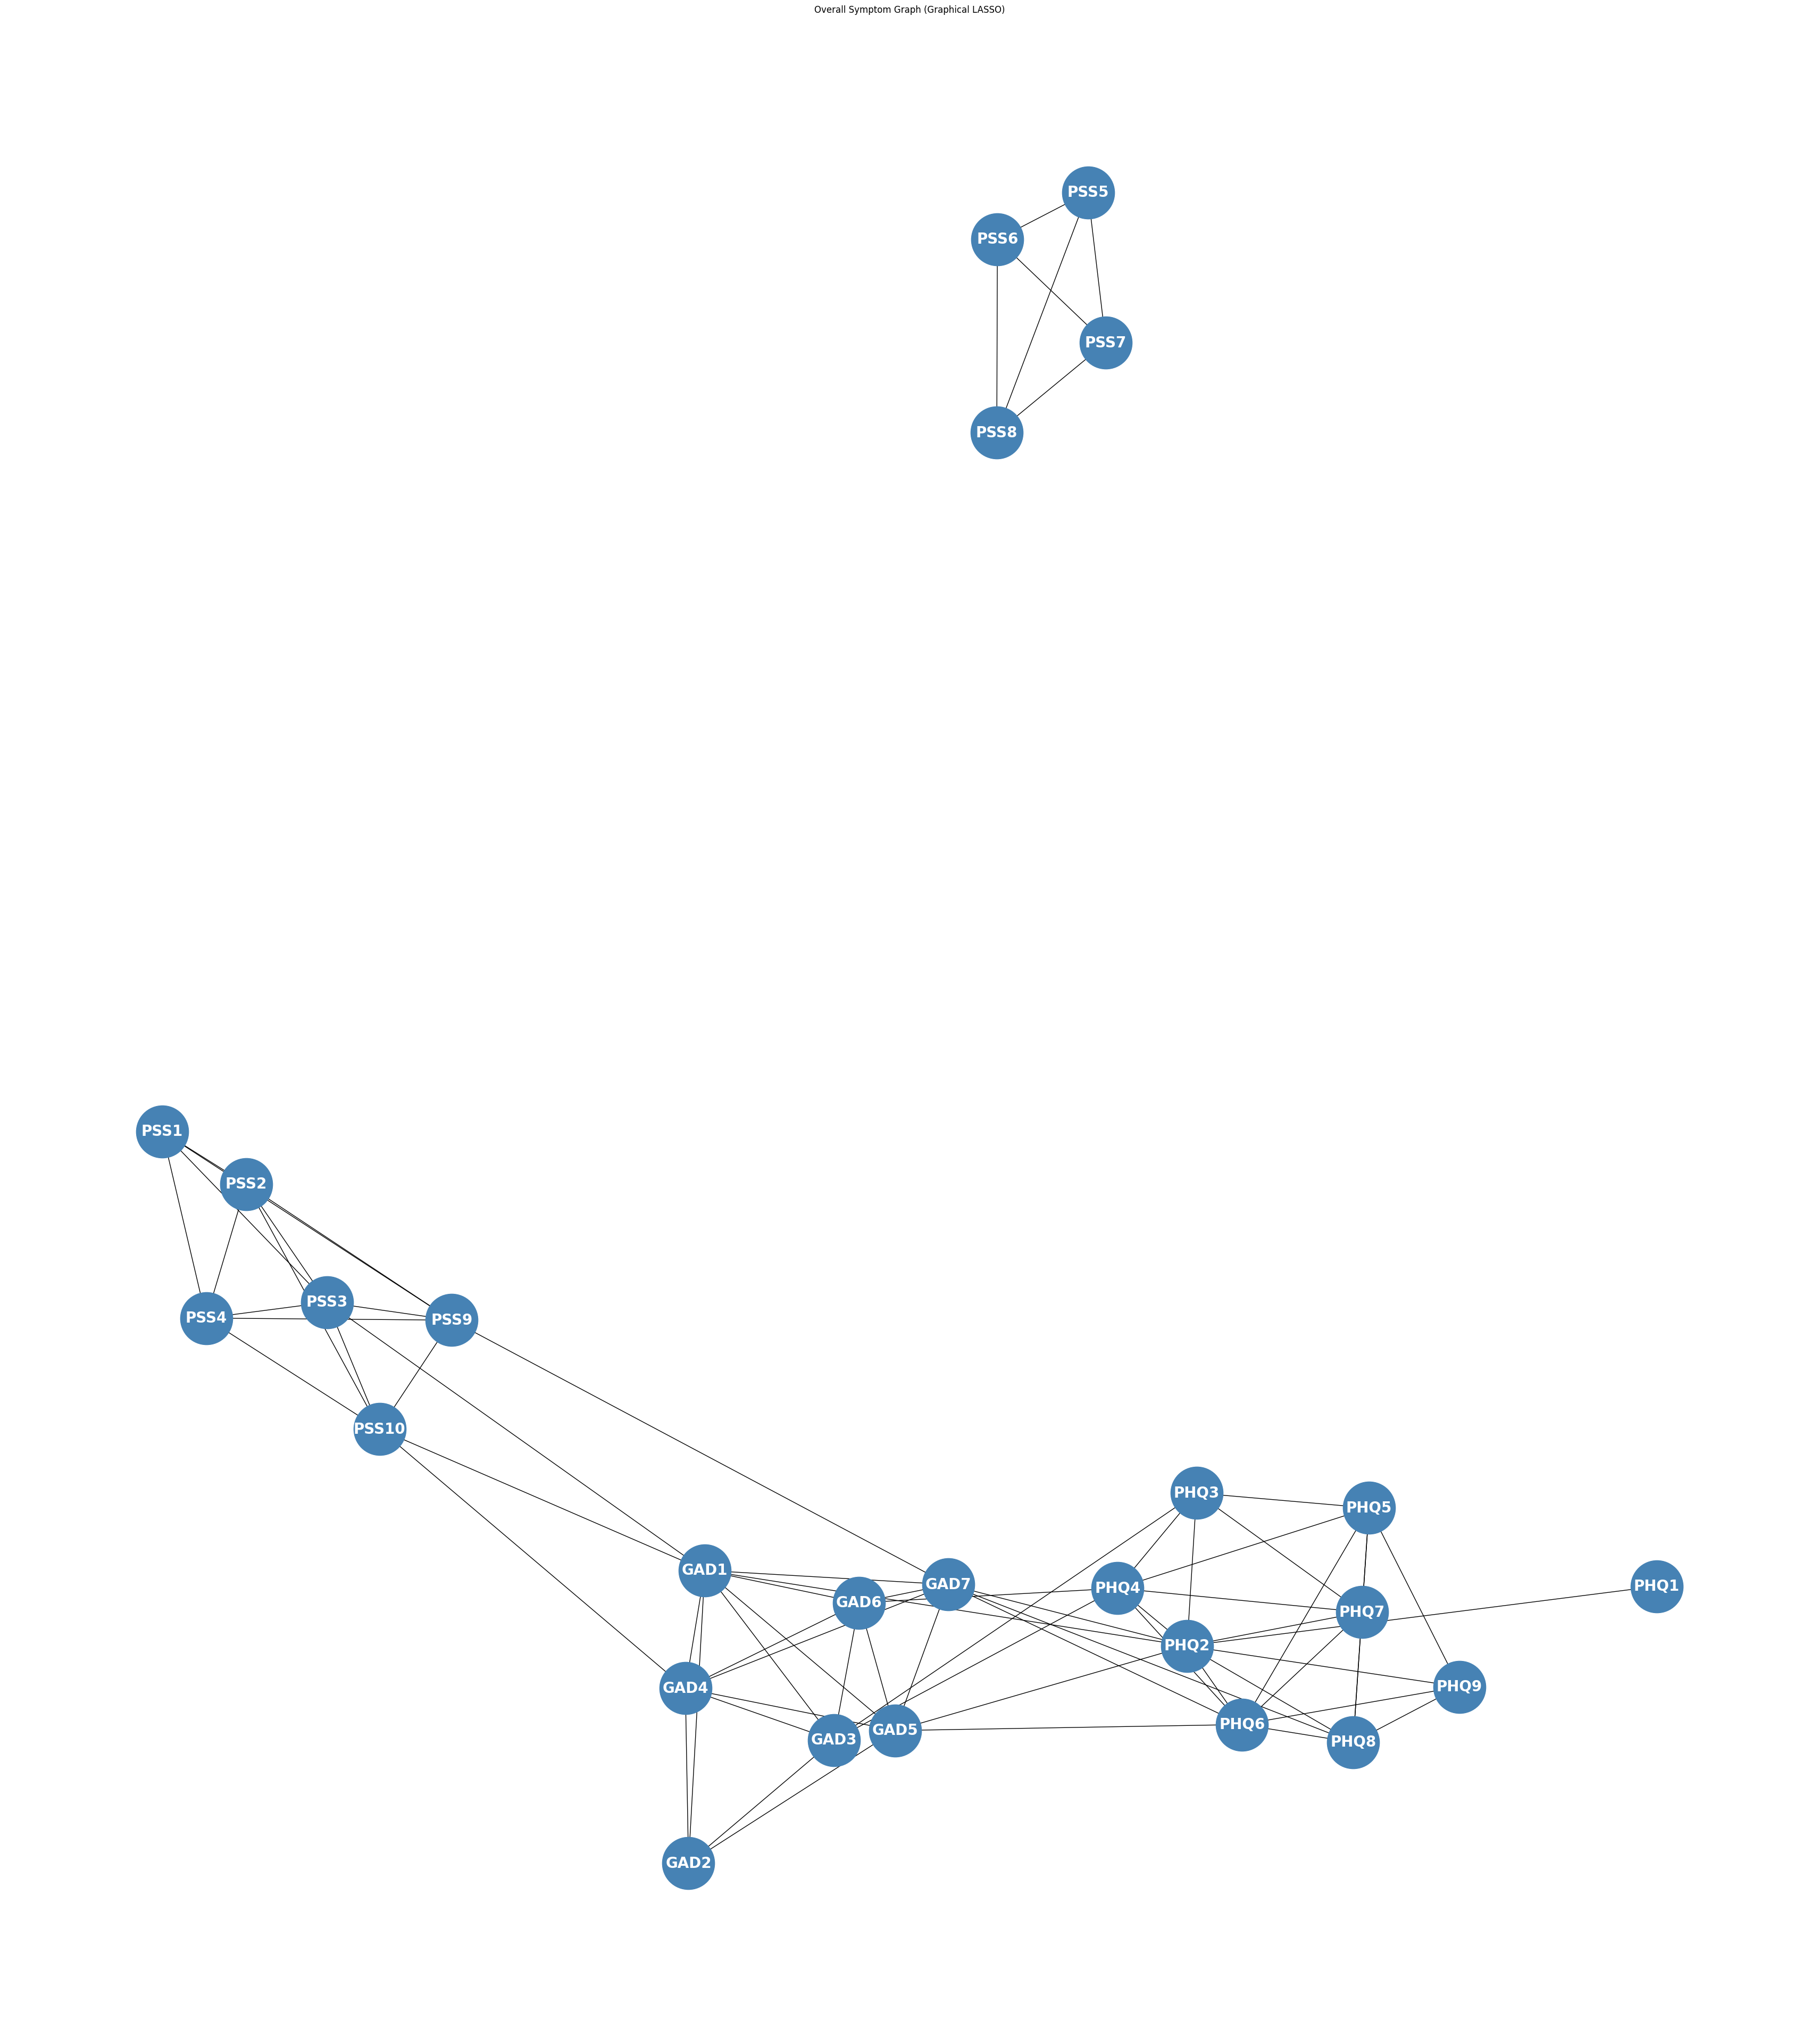

In [9]:
G = nx.from_numpy_array(adj_matrix)
mapping = {i: symptom_cols[i] for i in range(len(symptom_cols))}
G = nx.relabel_nodes(G, mapping)

plt.figure(figsize=(34, 38))
pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=5000,
    font_size=20,
    font_weight='bold',
    font_color='white',
    node_color='#4682B4'   # Dark Goldenrod
)

plt.title("Overall Symptom Graph (Graphical LASSO)")
plt.show()

Number of nodes: 26
Number of edges: 72


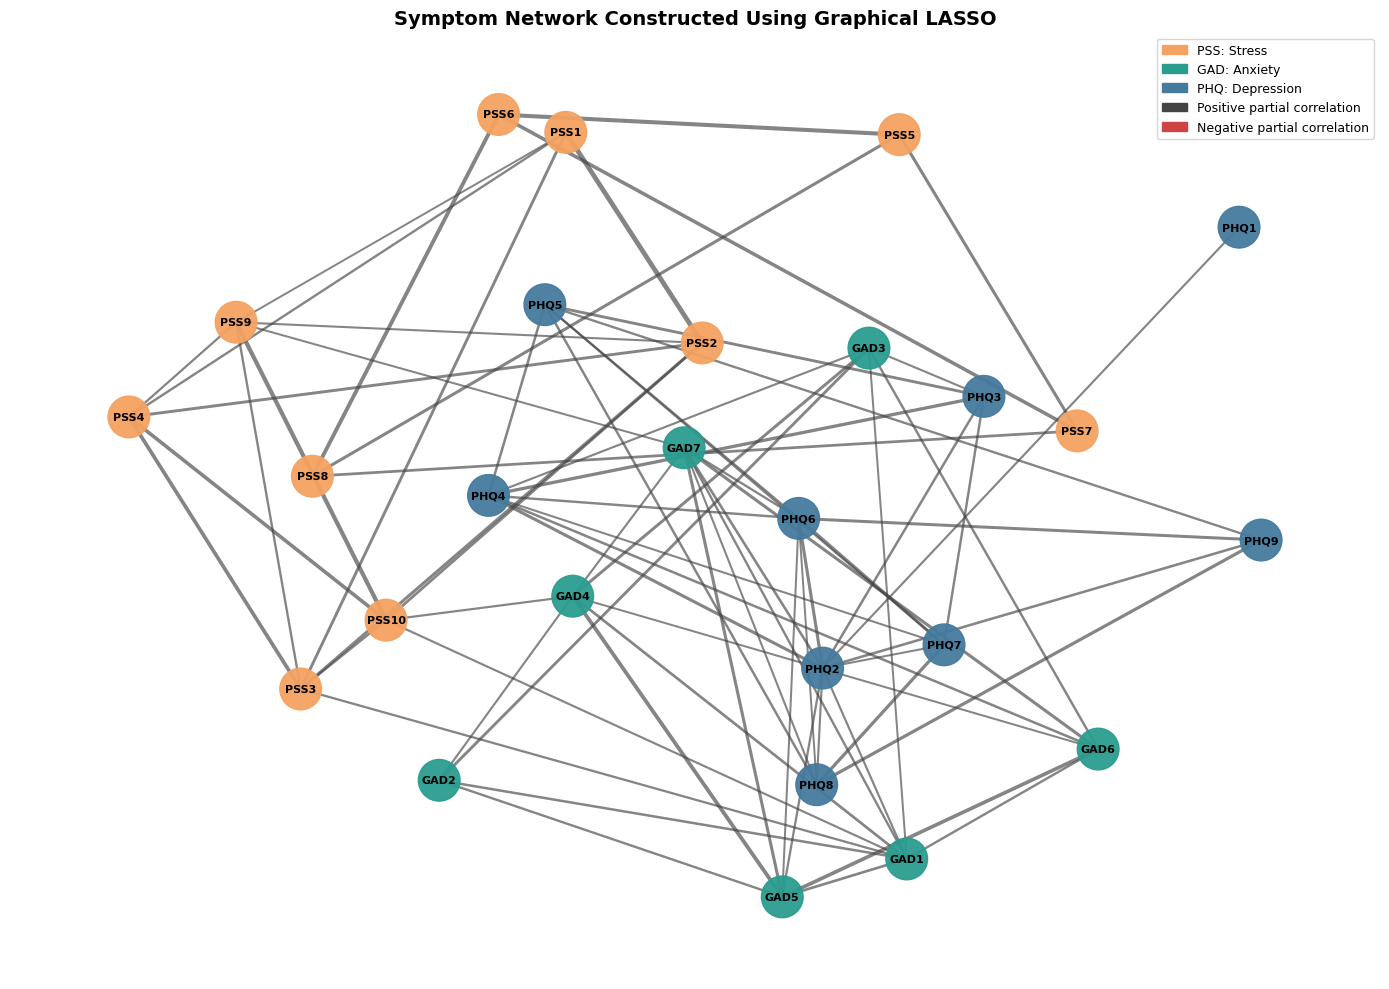

In [10]:
# =========================================================
# Visualize symptom graph with groups and edge weights
# =========================================================

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# Build undirected graph from adjacency matrix
G = nx.Graph()

# Add all symptom nodes, including isolated nodes
for col in symptom_cols:
    G.add_node(col)

# Add only upper-triangle edges to avoid duplicates
for i in range(len(symptom_cols)):
    for j in range(i + 1, len(symptom_cols)):
        weight = adj_matrix[i, j]
        if weight != 0:
            G.add_edge(
                symptom_cols[i],
                symptom_cols[j],
                weight=weight,
                abs_weight=abs(weight)
            )

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

# Node colors by questionnaire group
node_colors = []
for node in G.nodes():
    if node.startswith("PSS"):
        node_colors.append("#F4A261")  # Stress
    elif node.startswith("GAD"):
        node_colors.append("#2A9D8F")  # Anxiety
    elif node.startswith("PHQ"):
        node_colors.append("#457B9D")  # Depression
    else:
        node_colors.append("#CCCCCC")

# Edge widths by absolute partial correlation
edge_widths = [
    1 + 8 * G[u][v]["abs_weight"]
    for u, v in G.edges()
]

# Edge styles/colors: positive vs negative partial correlation
edge_colors = [
    "#444444" if G[u][v]["weight"] > 0 else "#CC4444"
    for u, v in G.edges()
]

plt.figure(figsize=(14, 10))

pos = nx.spring_layout(
    G,
    seed=42,
    k=0.8
)

nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    node_size=900,
    alpha=0.95
)

nx.draw_networkx_edges(
    G,
    pos,
    width=edge_widths,
    edge_color=edge_colors,
    alpha=0.65
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=8,
    font_weight="bold"
)

# Manual legend
import matplotlib.patches as mpatches

legend_items = [
    mpatches.Patch(color="#F4A261", label="PSS: Stress"),
    mpatches.Patch(color="#2A9D8F", label="GAD: Anxiety"),
    mpatches.Patch(color="#457B9D", label="PHQ: Depression"),
    mpatches.Patch(color="#444444", label="Positive partial correlation"),
    mpatches.Patch(color="#CC4444", label="Negative partial correlation")
]

plt.legend(
    handles=legend_items,
    loc="best",
    fontsize=9,
    frameon=True
)

plt.title(
    "Symptom Network Constructed Using Graphical LASSO",
    fontsize=14,
    fontweight="bold"
)

plt.axis("off")
plt.tight_layout()
plt.show()

Number of nodes: 26
Number of edges: 72


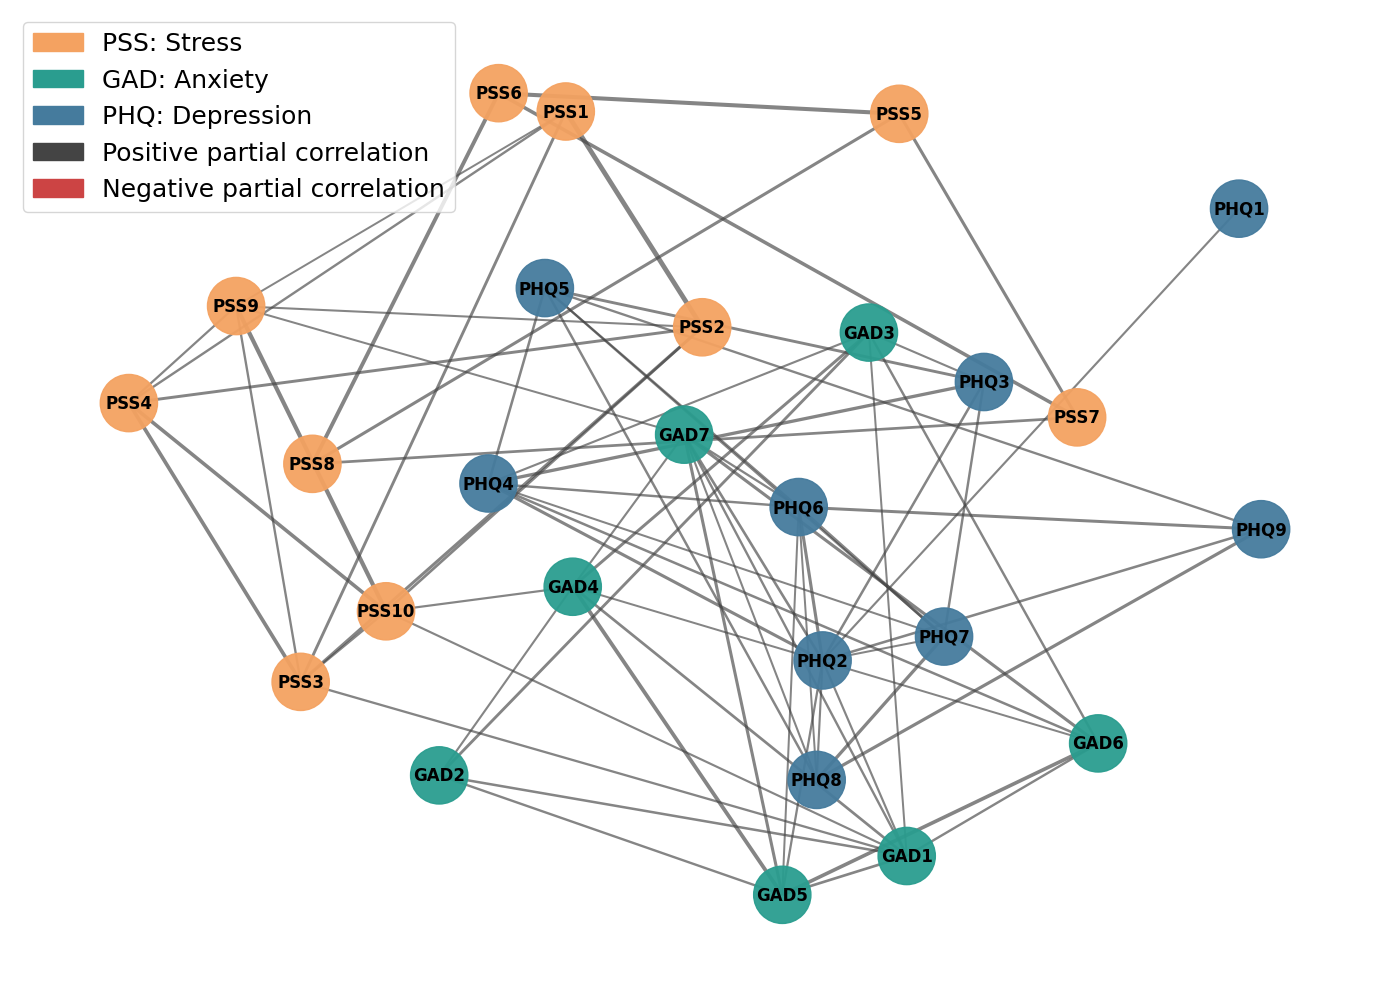

In [25]:
# =========================================================
# Visualize symptom graph with groups and edge weights
# =========================================================

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# Build undirected graph from adjacency matrix
G = nx.Graph()

# Add all symptom nodes, including isolated nodes
for col in symptom_cols:
    G.add_node(col)

# Add only upper-triangle edges to avoid duplicates
for i in range(len(symptom_cols)):
    for j in range(i + 1, len(symptom_cols)):
        weight = adj_matrix[i, j]
        if weight != 0:
            G.add_edge(
                symptom_cols[i],
                symptom_cols[j],
                weight=weight,
                abs_weight=abs(weight)
            )

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

# Node colors by questionnaire group
node_colors = []
for node in G.nodes():
    if node.startswith("PSS"):
        node_colors.append("#F4A261")  # Stress
    elif node.startswith("GAD"):
        node_colors.append("#2A9D8F")  # Anxiety
    elif node.startswith("PHQ"):
        node_colors.append("#457B9D")  # Depression
    else:
        node_colors.append("#CCCCCC")

# Edge widths by absolute partial correlation
edge_widths = [
    1 + 8 * G[u][v]["abs_weight"]
    for u, v in G.edges()
]

# Edge styles/colors: positive vs negative partial correlation
edge_colors = [
    "#444444" if G[u][v]["weight"] > 0 else "#CC4444"
    for u, v in G.edges()
]

plt.figure(figsize=(14, 10))

pos = nx.spring_layout(
    G,
    seed=42,
    k=0.8
)

nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    node_size=1700,
    alpha=.95
)

nx.draw_networkx_edges(
    G,
    pos,
    width=edge_widths,
    edge_color=edge_colors,
    alpha=0.65
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=12,
    font_weight="bold"
)

# Manual legend
import matplotlib.patches as mpatches

legend_items = [
    mpatches.Patch(color="#F4A261", label="PSS: Stress"),
    mpatches.Patch(color="#2A9D8F", label="GAD: Anxiety"),
    mpatches.Patch(color="#457B9D", label="PHQ: Depression"),
    mpatches.Patch(color="#444444", label="Positive partial correlation"),
    mpatches.Patch(color="#CC4444", label="Negative partial correlation")
]

plt.legend(
    handles=legend_items,
    loc="best",
    fontsize=18,
    frameon=True
)

# plt.title(
#     "Symptom Network Constructed Using Graphical LASSO",
#     fontsize=14,
#     fontweight="bold"
# )

plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Symptom matrix shape: (2028, 26)
First 3 rows after scaling:
 [[ 0.5513849   1.4467218   0.25785107 -0.30213417 -0.15962365 -0.71998272
   0.06626399  0.24565727  1.33715904  1.34106426  0.23307104  0.35613152
   1.25059497  0.22530815  0.13658529  0.20419359  0.25288159  0.56135718
   0.19782292  1.26306926  0.04402909  0.47697301  0.1948299   0.3501842
   1.52066023  0.72135678]
 [ 0.5513849   0.58201452  1.14116521 -0.30213417  0.76264634  0.19031962
   0.06626399  0.24565727 -0.36193778  0.48366252 -0.81730244  0.35613152
   0.24655435 -0.8108028  -0.88177858  1.21174735  0.25288159  1.60771045
   0.19782292  0.31856172  0.04402909  0.47697301  0.1948299   0.3501842
   0.54659234  0.72135678]
 [-1.99385466 -2.01210733 -2.39209134 -1.93825728 -2.00416364 -0.71998272
  -1.89553692 -1.5209844  -2.06103461 -2.08854271 -1.86767591 -1.5905928
  -1.76152688 -1.84691375 -1.90014246 -1.81091394 -1.6395312  -1.53134936
  -1.73559819 -1.57045337 -2.00863745 -1.43847503 -1.66892028 -1.59816577

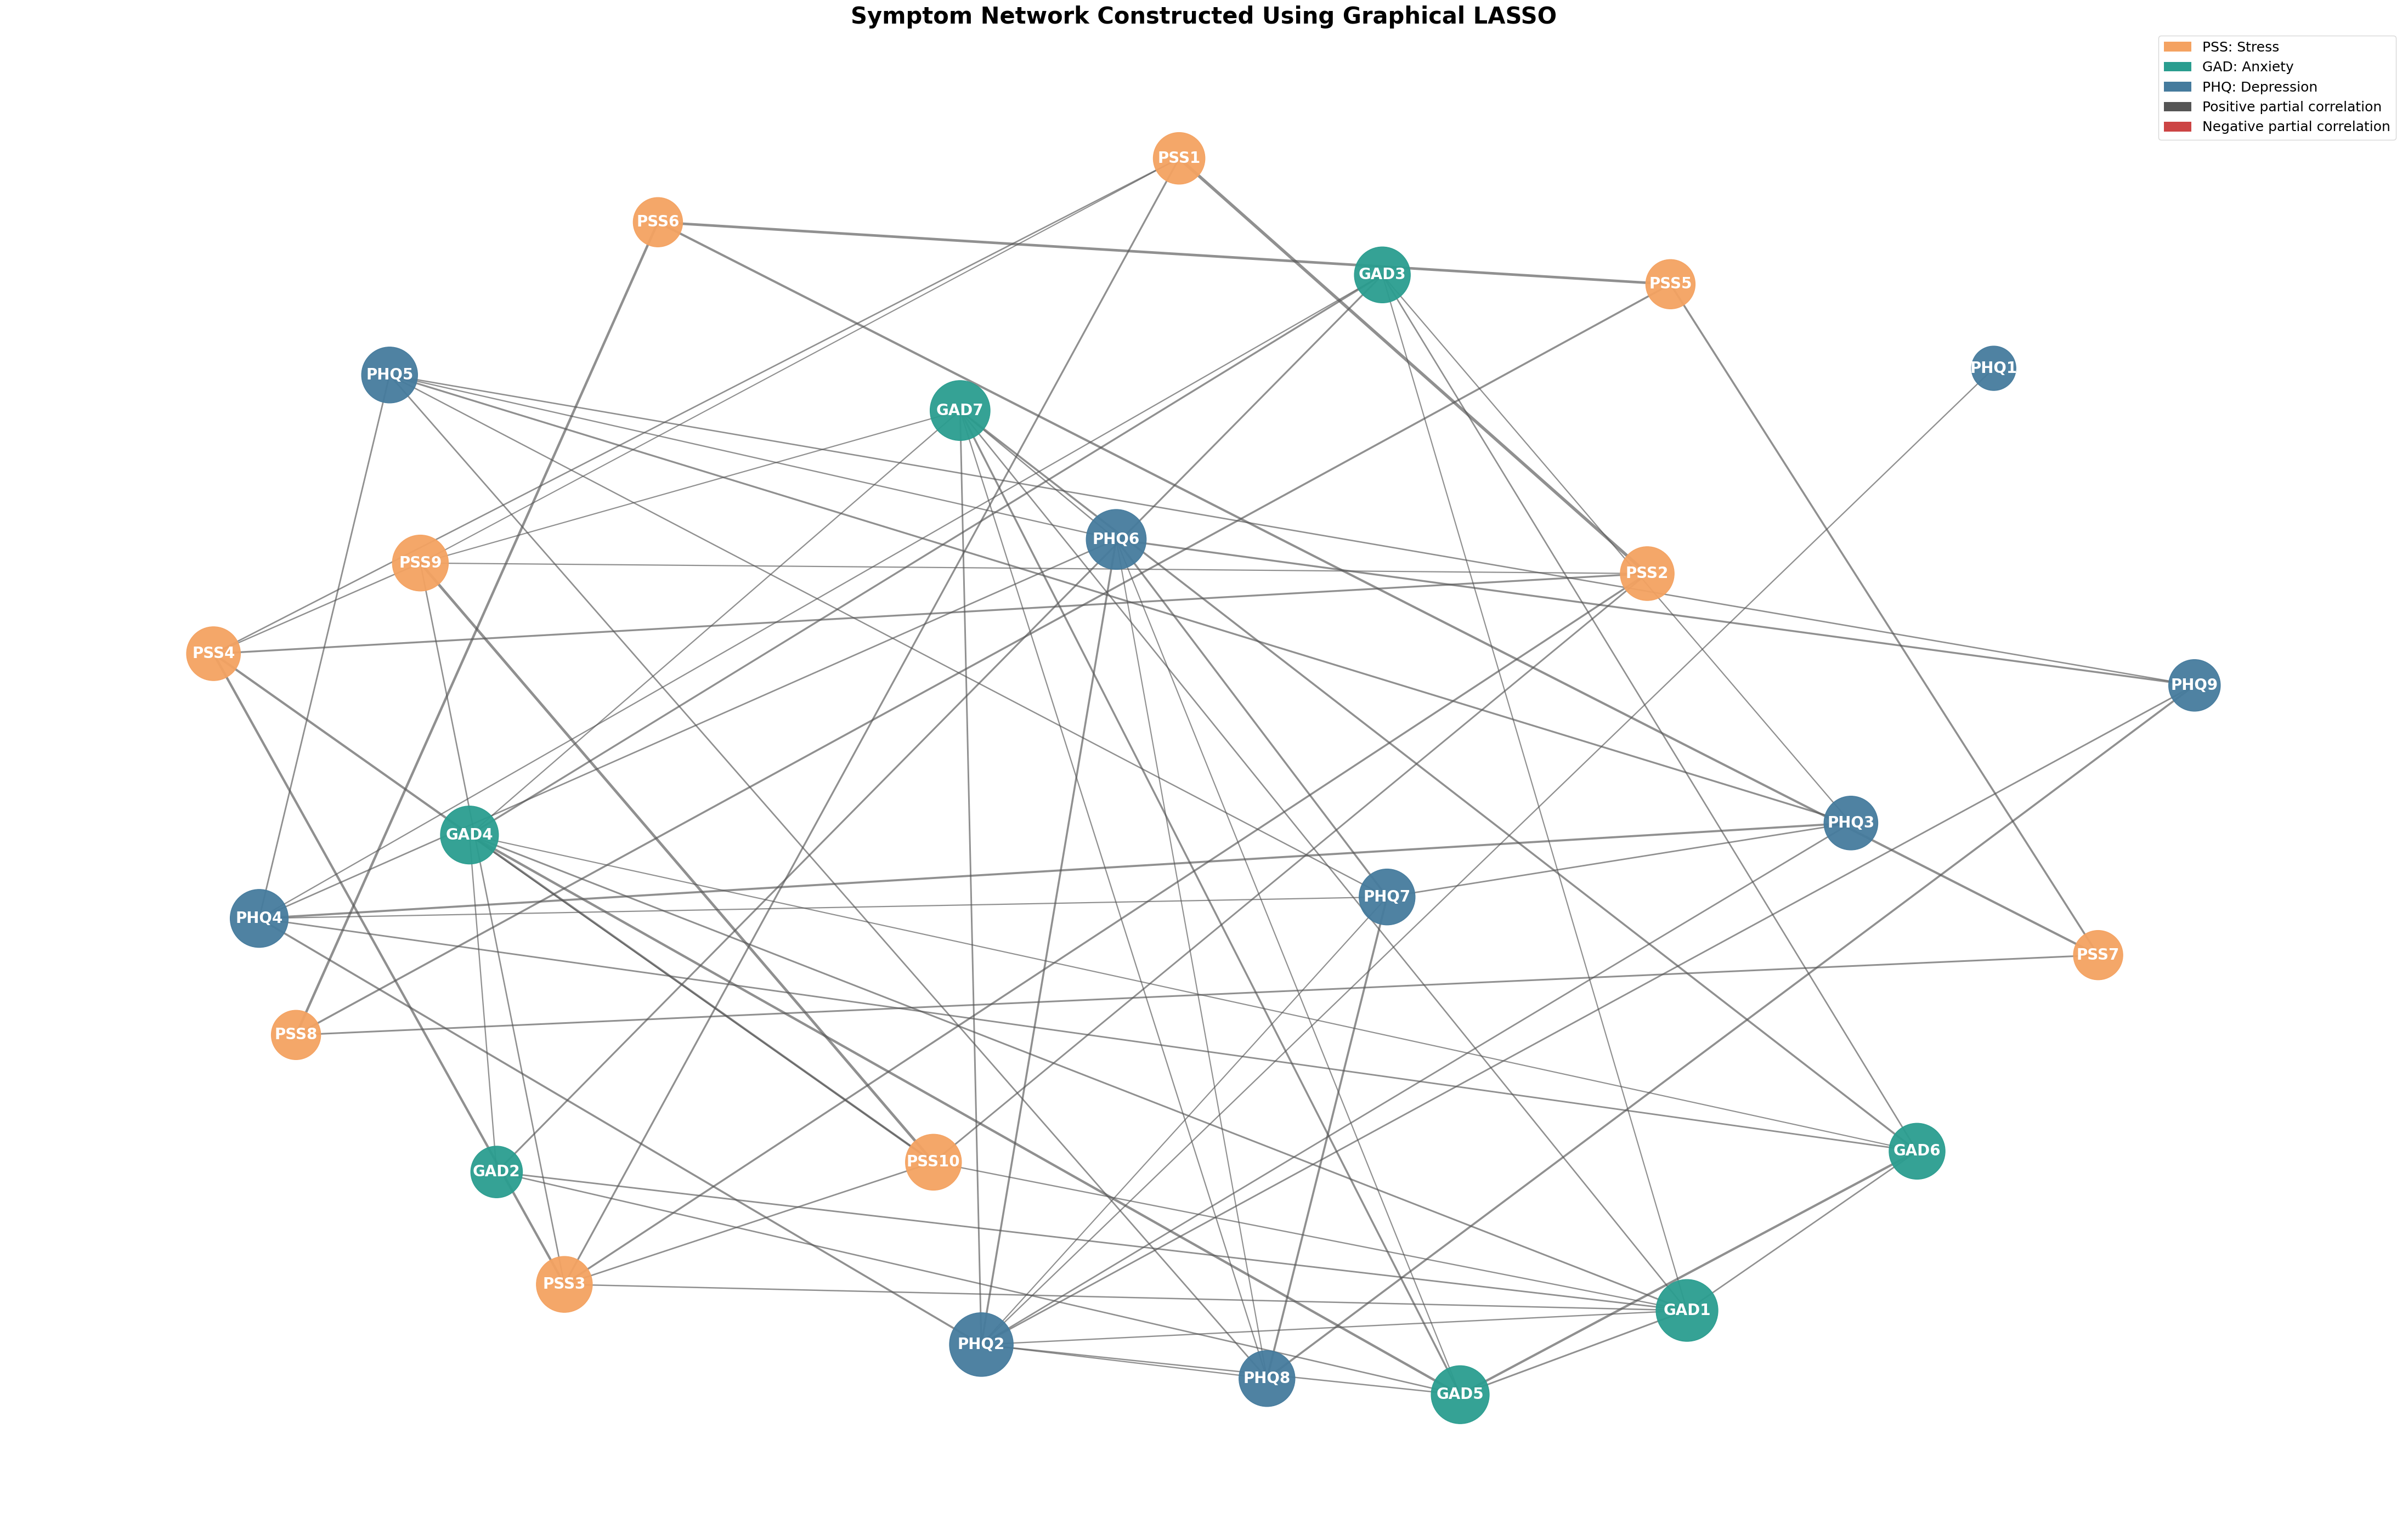

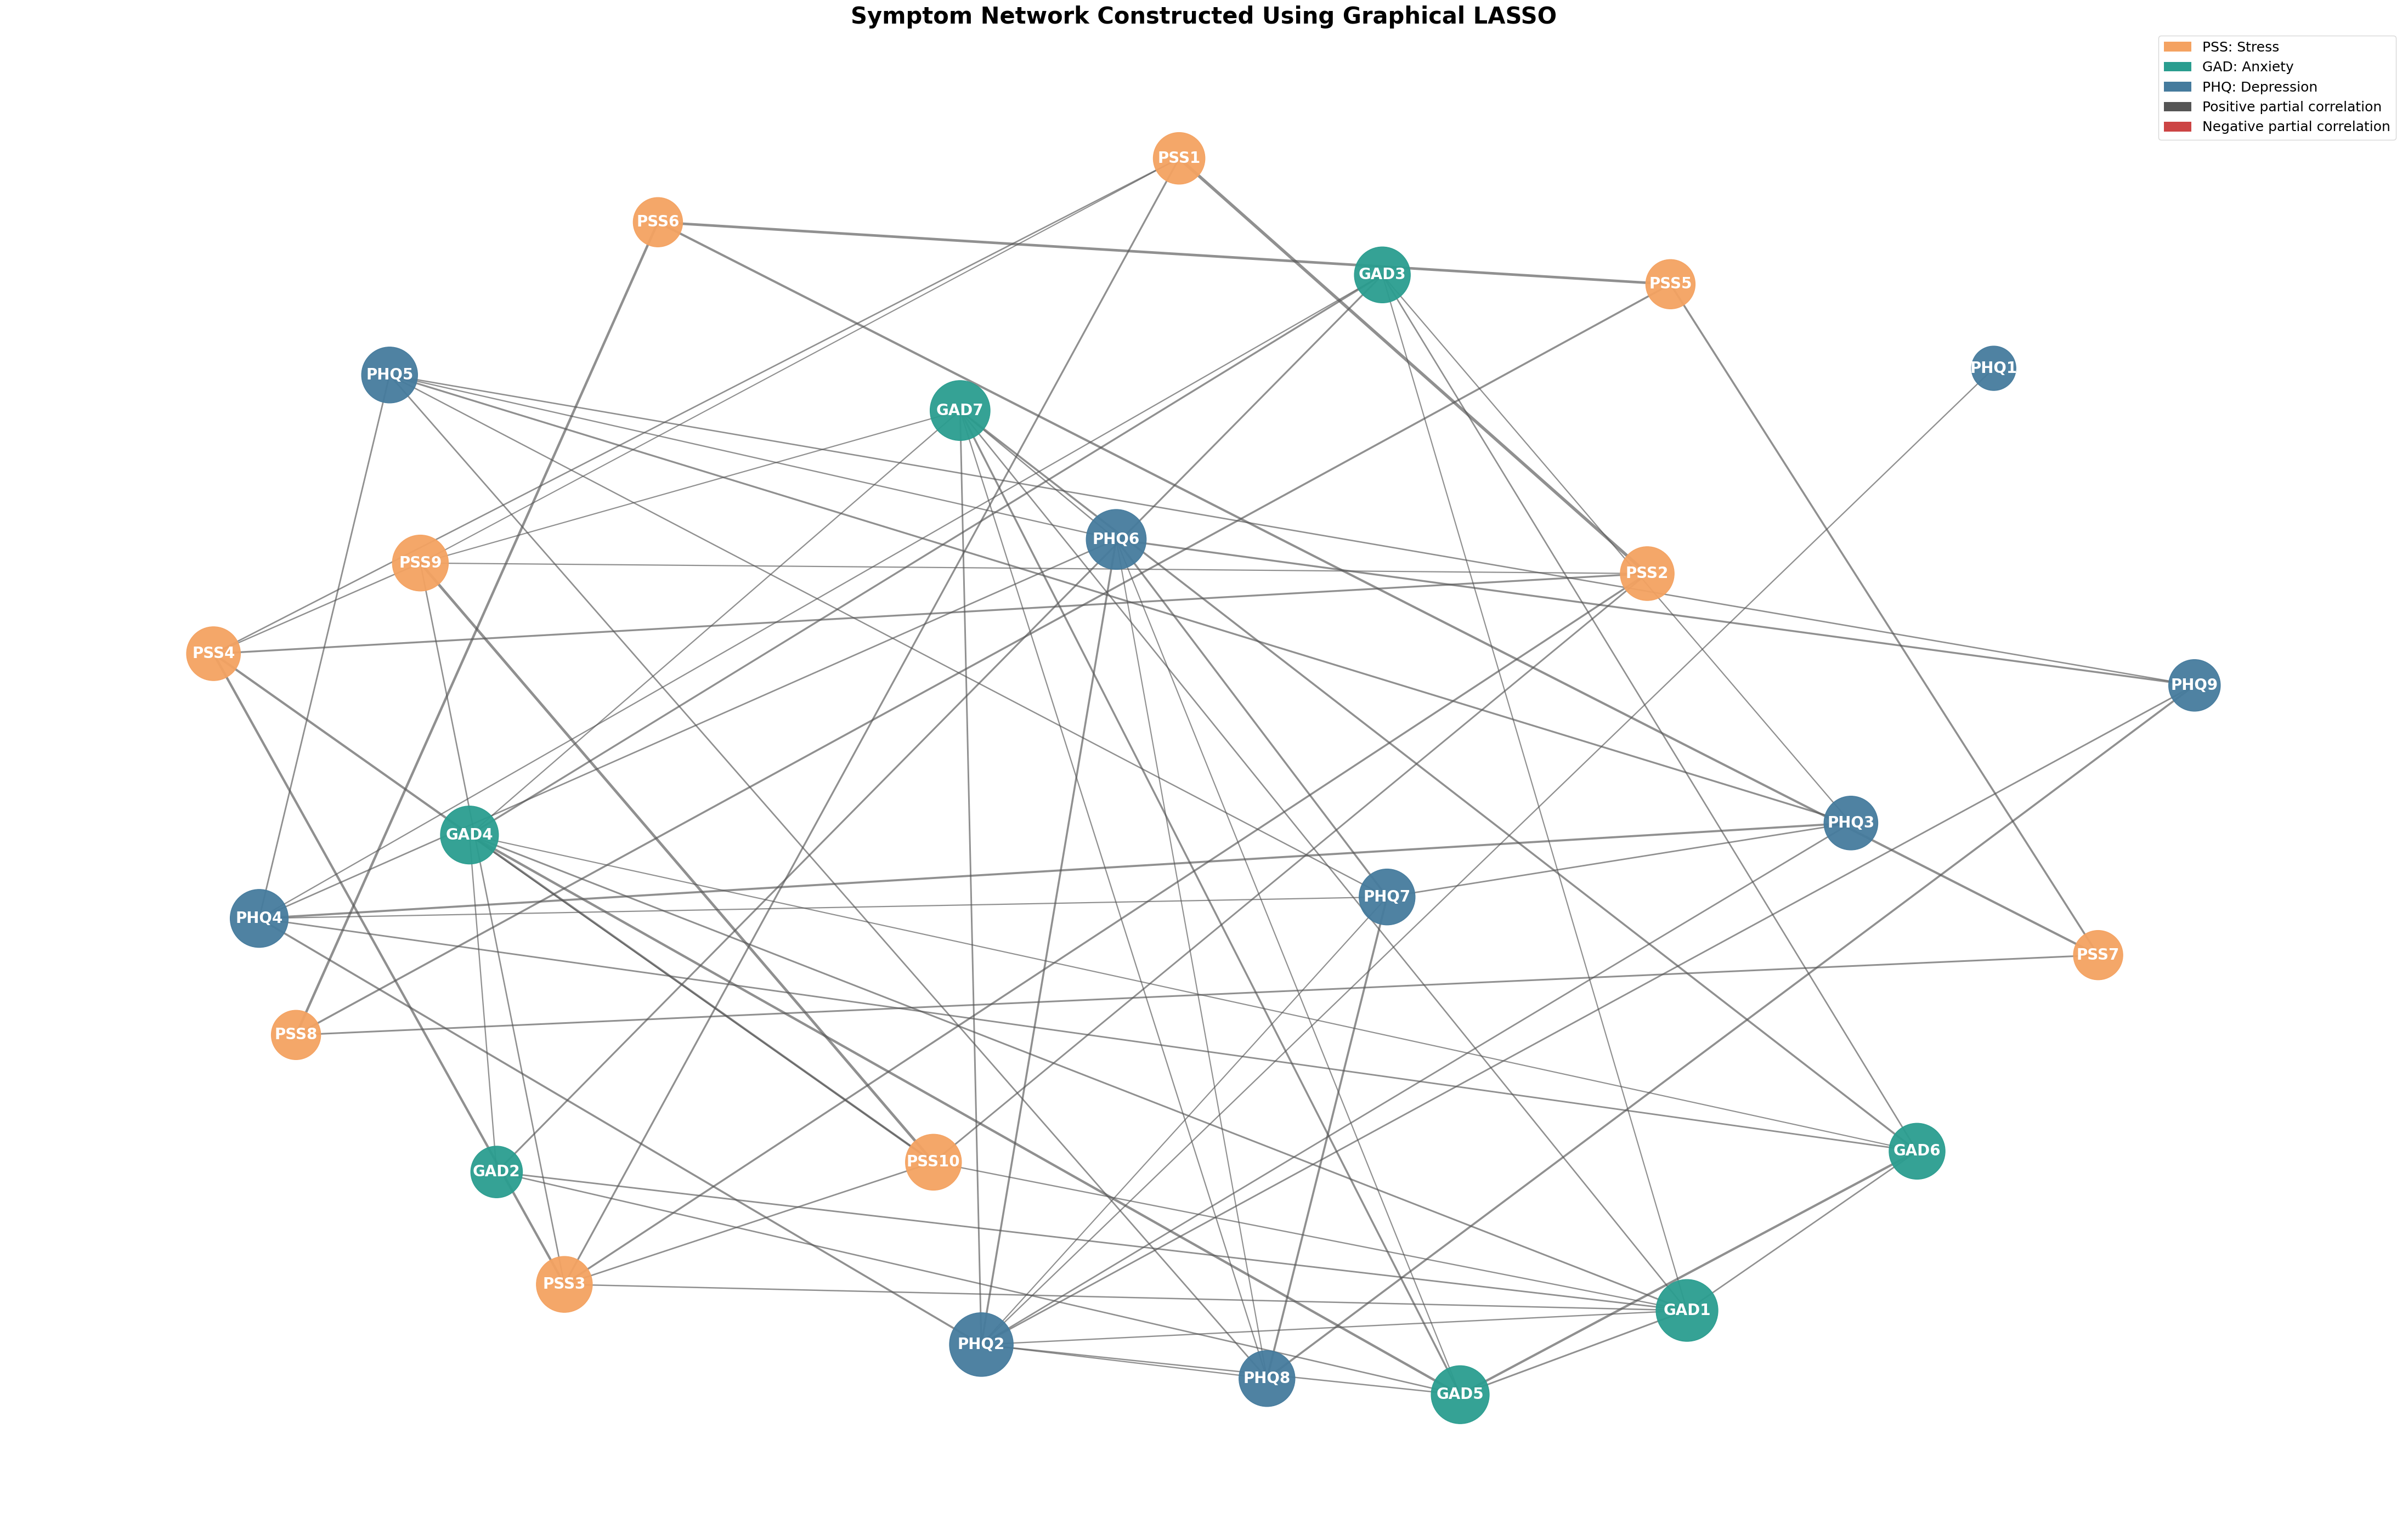


Top symptom connections:
   Feature_1 Feature_2  Partial_Correlation  Absolute_Weight
0       PSS1      PSS2             0.304539         0.304539
20      PSS9     PSS10             0.251763         0.251763
14      PSS5      PSS6             0.240233         0.240233
18      PSS6      PSS8             0.223616         0.223616
38      GAD4      GAD5             0.217590         0.217590
8       PSS3      PSS4             0.209127         0.209127
41      GAD5      GAD6             0.202324         0.202324
13      PSS4     PSS10             0.199717         0.199717
17      PSS6      PSS7             0.193976         0.193976
57      PHQ3      PHQ4             0.171377         0.171377
70      PHQ7      PHQ8             0.168657         0.168657
71      PHQ8      PHQ9             0.163002         0.163002
53      PHQ2      PHQ6             0.156180         0.156180
52      PHQ2      PHQ4             0.155604         0.155604
45      GAD6      GAD7             0.155456         0.15545

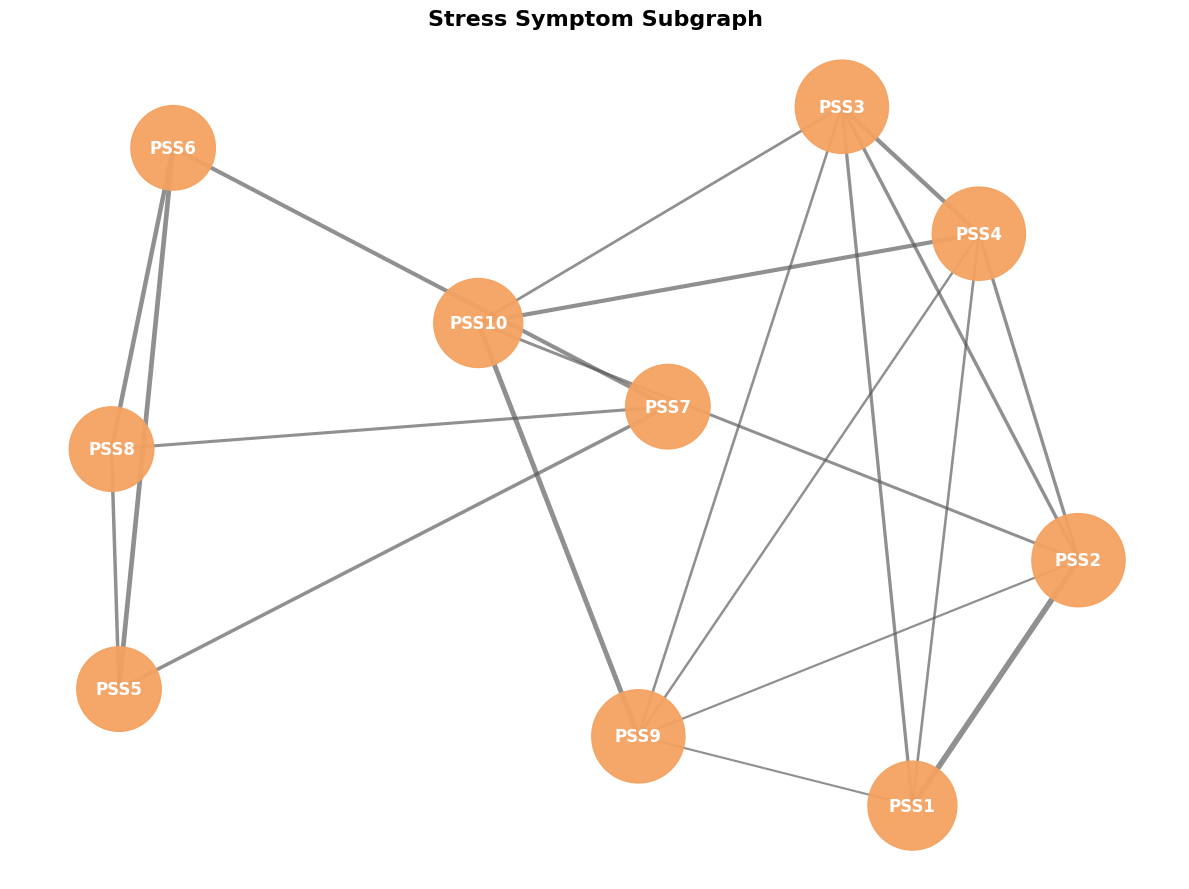

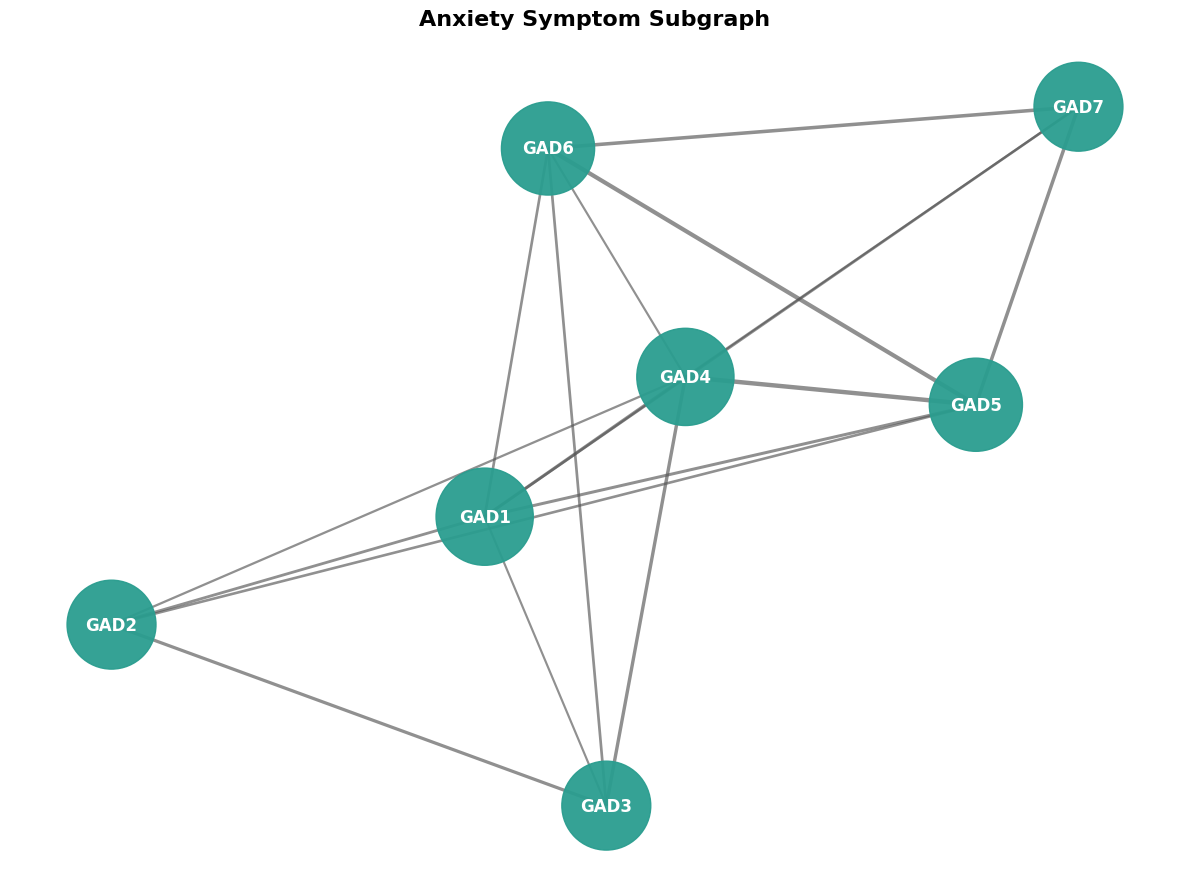

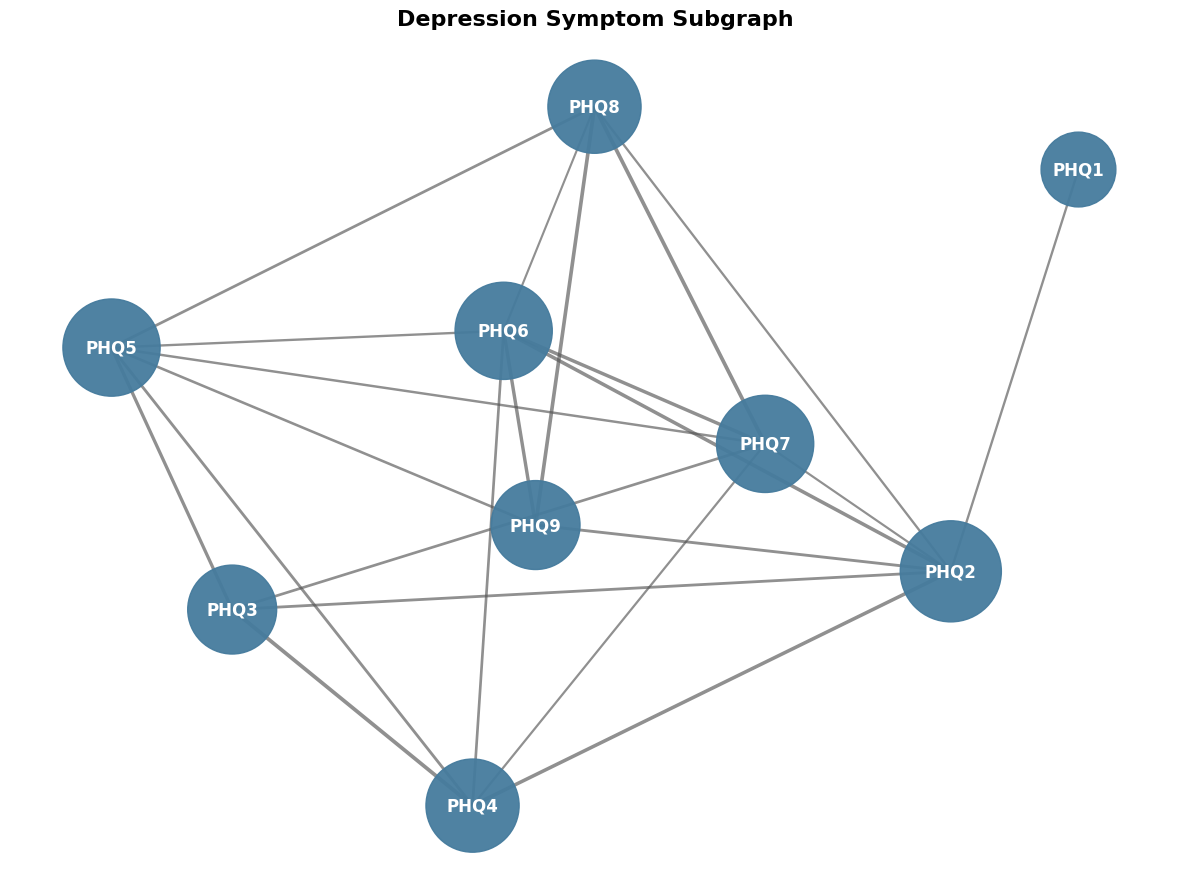

In [ ]:



# =========================================================
# Symptom Network Analysis using Graphical LASSO
# Purpose:
# - Explore relationships among PSS, GAD, and PHQ symptoms
# - Support the stress-guided PsyFormer concept
# - This graph is NOT used for model training, feature selection, or prediction
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import torch

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.covariance import GraphicalLassoCV
from matplotlib.patches import Patch


# =========================================================
# 1. Define symptom columns
# =========================================================

stress_cols = [
    'PSS1', 'PSS2', 'PSS3', 'PSS4', 'PSS5',
    'PSS6', 'PSS7', 'PSS8', 'PSS9', 'PSS10'
]

anxiety_cols = [
    'GAD1', 'GAD2', 'GAD3', 'GAD4',
    'GAD5', 'GAD6', 'GAD7'
]

depression_cols = [
    'PHQ1', 'PHQ2', 'PHQ3', 'PHQ4', 'PHQ5',
    'PHQ6', 'PHQ7', 'PHQ8', 'PHQ9'
]

symptom_cols = stress_cols + anxiety_cols + depression_cols


# =========================================================
# 2. Prepare symptom matrix
# =========================================================

X_symptom = data[symptom_cols].copy()

# Convert all symptom columns to numeric
for col in symptom_cols:
    X_symptom[col] = pd.to_numeric(X_symptom[col], errors='coerce')

# Median imputation
symptom_imputer = SimpleImputer(strategy='median')
X_symptom_imputed = symptom_imputer.fit_transform(X_symptom)

# Standardization
symptom_scaler = StandardScaler()
X_symptom_scaled = symptom_scaler.fit_transform(X_symptom_imputed)

print("Symptom matrix shape:", X_symptom_scaled.shape)
print("First 3 rows after scaling:\n", X_symptom_scaled[:3])


# =========================================================
# 3. Construct symptom graph using Graphical LASSO
# =========================================================

glasso = GraphicalLassoCV()
glasso.fit(X_symptom_scaled)

precision_matrix = glasso.precision_


def precision_to_partial_corr(precision):
    """
    Convert precision matrix to partial correlation matrix.
    """
    d = np.sqrt(np.diag(precision))
    partial_corr = -precision / np.outer(d, d)
    np.fill_diagonal(partial_corr, 0.0)
    return partial_corr


partial_corr_matrix = precision_to_partial_corr(precision_matrix)

# Threshold for edge creation
threshold = 0.05

adj_matrix = partial_corr_matrix.copy()
adj_matrix[np.abs(adj_matrix) < threshold] = 0.0

# Optional PyTorch edge format, if needed later for graph-based experiments
src, dst = np.nonzero(adj_matrix)

edge_index = torch.tensor(
    np.vstack((src, dst)),
    dtype=torch.long
)

edge_weight = torch.tensor(
    adj_matrix[src, dst],
    dtype=torch.float
)

print("Number of symptom nodes:", len(symptom_cols))
print("Number of directed edges:", edge_index.shape[1])


# =========================================================
# 4. Build NetworkX graph
# =========================================================

G = nx.Graph()

# Add all nodes, including isolated nodes
for node in symptom_cols:
    G.add_node(node)

# Add only upper-triangle edges to avoid duplicate undirected edges
for i in range(len(symptom_cols)):
    for j in range(i + 1, len(symptom_cols)):
        weight = adj_matrix[i, j]

        if weight != 0:
            G.add_edge(
                symptom_cols[i],
                symptom_cols[j],
                weight=weight,
                abs_weight=abs(weight)
            )

print("Number of graph nodes:", G.number_of_nodes())
print("Number of graph edges:", G.number_of_edges())


# =========================================================
# 5. Node colors by questionnaire type
# =========================================================

node_colors = []

for node in G.nodes():
    if node.startswith("PSS"):
        node_colors.append("#F4A261")   # Stress - orange
    elif node.startswith("GAD"):
        node_colors.append("#2A9D8F")   # Anxiety - green
    elif node.startswith("PHQ"):
        node_colors.append("#457B9D")   # Depression - blue
    else:
        node_colors.append("#CCCCCC")


# =========================================================
# 6. Node size based on degree centrality
# =========================================================

degree_dict = dict(G.degree())

node_sizes = [
    3000 + degree_dict[node] * 400
    for node in G.nodes()
]


# =========================================================
# 7. Edge width and color
# =========================================================

edge_widths = []
edge_colors = []

for u, v in G.edges():
    weight = G[u][v]["weight"]
    abs_weight = G[u][v]["abs_weight"]

    edge_widths.append(1 + 10 * abs_weight)

    if weight > 0:
        edge_colors.append("#555555")   # Positive partial correlation
    else:
        edge_colors.append("#CC4444")   # Negative partial correlation


# =========================================================
# 8. Visualize overall symptom network
# =========================================================

plt.figure(figsize=(44, 28))

pos = nx.spring_layout(
    G,
    seed=42,
    k=1.2
)

nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    node_size=node_sizes,
    alpha=0.95
)

nx.draw_networkx_edges(
    G,
    pos,
    width=edge_widths,
    edge_color=edge_colors,
    alpha=0.65
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=20,
    font_weight="bold",
    font_color="white"
)

legend_elements = [
    Patch(facecolor="#F4A261", label="PSS: Stress"),
    Patch(facecolor="#2A9D8F", label="GAD: Anxiety"),
    Patch(facecolor="#457B9D", label="PHQ: Depression"),
    Patch(facecolor="#555555", label="Positive partial correlation"),
    Patch(facecolor="#CC4444", label="Negative partial correlation")
]

plt.legend(
    handles=legend_elements,
    fontsize=18,
    loc="upper right",
    frameon=True
)

plt.title(
    "Symptom Network Constructed Using Graphical LASSO",
    fontsize=30,
    fontweight="bold"
)

plt.axis("off")
plt.tight_layout()
plt.show()


# =========================================================
# 9. Optional: Save high-resolution figure
# =========================================================

plt.figure(figsize=(44, 28))

nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    node_size=node_sizes,
    alpha=0.95
)

nx.draw_networkx_edges(
    G,
    pos,
    width=edge_widths,
    edge_color=edge_colors,
    alpha=0.65
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=20,
    font_weight="bold",
    font_color="white"
)

plt.legend(
    handles=legend_elements,
    fontsize=18,
    loc="upper right",
    frameon=True
)

plt.title(
    "Symptom Network Constructed Using Graphical LASSO",
    fontsize=30,
    fontweight="bold"
)

plt.axis("off")
plt.tight_layout()

plt.savefig(
    "symptom_network_graphical_lasso.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "symptom_network_graphical_lasso.pdf",
    bbox_inches="tight"
)

plt.show()


# =========================================================
# 10. Optional: Print strongest edges
# =========================================================

edge_table = []

for u, v, attr in G.edges(data=True):
    edge_table.append({
        "Feature_1": u,
        "Feature_2": v,
        "Partial_Correlation": attr["weight"],
        "Absolute_Weight": attr["abs_weight"]
    })

edge_df = pd.DataFrame(edge_table)

edge_df = edge_df.sort_values(
    by="Absolute_Weight",
    ascending=False
)

print("\nTop symptom connections:")
print(edge_df.head(20))


# =========================================================
# 11. Optional: Save edge table
# =========================================================

edge_df.to_csv(
    "symptom_network_edges.csv",
    index=False
)


# =========================================================
# 12. Optional: Plot subgraphs
# =========================================================

def plot_subgraph(node_names, title):
    SG = G.subgraph(node_names).copy()

    sub_node_colors = []

    for node in SG.nodes():
        if node.startswith("PSS"):
            sub_node_colors.append("#F4A261")
        elif node.startswith("GAD"):
            sub_node_colors.append("#2A9D8F")
        elif node.startswith("PHQ"):
            sub_node_colors.append("#457B9D")
        else:
            sub_node_colors.append("#CCCCCC")

    sub_degree_dict = dict(SG.degree())

    sub_node_sizes = [
        2500 + sub_degree_dict[node] * 400
        for node in SG.nodes()
    ]

    sub_edge_widths = [
        1 + 10 * SG[u][v]["abs_weight"]
        for u, v in SG.edges()
    ]

    sub_edge_colors = [
        "#555555" if SG[u][v]["weight"] > 0 else "#CC4444"
        for u, v in SG.edges()
    ]

    plt.figure(figsize=(12, 9))

    sub_pos = nx.spring_layout(
        SG,
        seed=42,
        k=1.0
    )

    nx.draw_networkx_nodes(
        SG,
        sub_pos,
        node_color=sub_node_colors,
        node_size=sub_node_sizes,
        alpha=0.95
    )

    nx.draw_networkx_edges(
        SG,
        sub_pos,
        width=sub_edge_widths,
        edge_color=sub_edge_colors,
        alpha=0.65
    )

    nx.draw_networkx_labels(
        SG,
        sub_pos,
        font_size=12,
        font_weight="bold",
        font_color="white"
    )

    plt.title(
        title,
        fontsize=16,
        fontweight="bold"
    )

    plt.axis("off")
    plt.tight_layout()
    plt.show()


plot_subgraph(stress_cols, "Stress Symptom Subgraph")
plot_subgraph(anxiety_cols, "Anxiety Symptom Subgraph")
plot_subgraph(depression_cols, "Depression Symptom Subgraph")
